# Lecture 12 – Visualization I

### DATA 2201, Fall 2026



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### Lecture Outline:
- Variable Types for Data Visualization
- Data Visualization Demo with Matplotlib & Seaborn Plot Library
  - Bar Plot
  - Box Plots and Violin Plots
  - Histogram

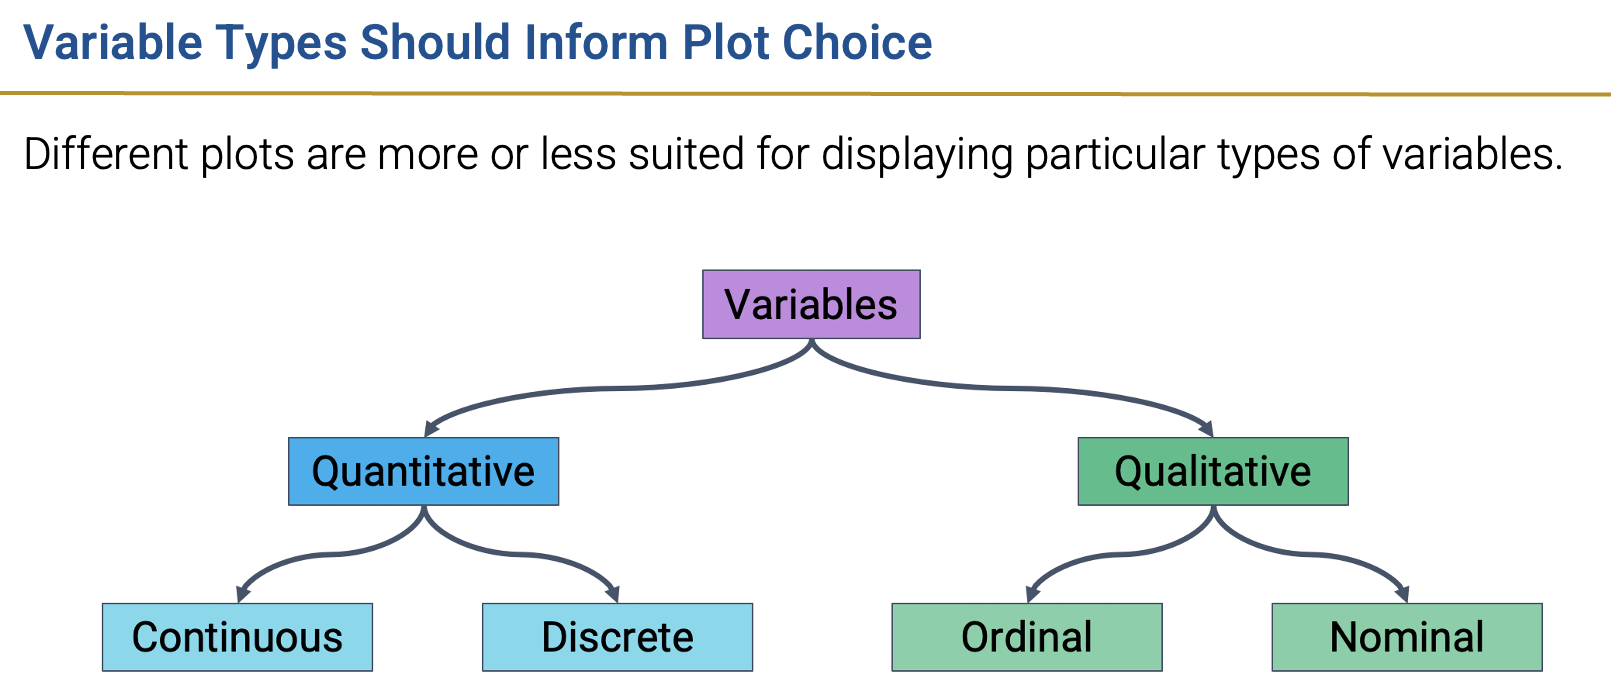

---

#### Variables can be split into two big groups:

  - **Quantitative (numeric):** things you can measure with numbers  
    - **Continuous:** values along a scale (e.g., height, weight, time)  
    - **Discrete:** whole number counts (e.g., number of pets, test scores)  

  - **Qualitative (categorical):** things you can label but not measure  
    - **Ordinal:** categories with a natural order (e.g., small, medium, large)  
    - **Nominal:** categories with no order (e.g., colors, names, types of fruit)  

👉 **Key idea:** Different variable types call for different plots.  For example: 
- histograms are good for continuous variables,
- bar plots for categorical variables, and
- box plots for comparing distributions.

---

#### Quiz: Variable Types

1. A dataset records the **daily temperature** (in °C) of a city.  
   - (a) Continuous  
   - (b) Discrete  
   - (c) Ordinal  
   - (d) Nominal  

2. A survey asks for **favorite type of cuisine** (Italian, Mexican, Indian, Chinese).  
   - (a) Continuous  
   - (b) Discrete  
   - (c) Ordinal  
   - (d) Nominal  

3. A clothing store records **t-shirt size** (S, M, L, XL).  
   - (a) Continuous  
   - (b) Discrete  
   - (c) Ordinal  
   - (d) Nominal  

4. A teacher counts the **number of students** absent in each class.  
   - (a) Continuous  
   - (b) Discrete  
   - (c) Ordinal  
   - (d) Nominal  

5. Students give a **rating of satisfaction**: low, medium, high.  
   - (a) Continuous  
   - (b) Discrete  
   - (c) Ordinal  
   - (d) Nominal  

---



<details>
<summary>Click to Show Answer Key:</summary>

<pre>

1 → (a) Continuous  
2 → (d) Nominal  
3 → (c) Ordinal  
4 → (b) Discrete  
5 → (c) Ordinal  

</pre>
</details>



#### Data Visualization Demo
- In this lecture, we will demonstrate visualization techniques on the World Bank dataset.
- This dataset includes information about countries and development statistics from around the world.

In [ ]:
wb = pd.read_csv("data/world_bank.csv", index_col=0)
wb.head()

In [ ]:
wb.shape

## Bar Plots

- We often use bar plots to display **distributions** of a **categorical variable**. 
- In the examples below, we plot the distribution of the `"Continent"` column.
- The cell below uses `.value_counts()` to determine the number of countries corresponding to each continent in the dataset.

In [ ]:
wb["Continent"].value_counts()

Those who took DATA 1202, you used the `datascience` library to generate plots. The code to plot the distribution of the `"Maternal Smoker"` column may have looked like this:
```python

from datascience import Table
t = Table.from_df(wb["Continent"].value_counts().reset_index())
t.barh("index", "Continent")
```

## Matplotlib & Seaborn Ploting Library
- In DATA 2201, we will mainly use the [Matplotlib](https://matplotlib.org/stable/api/index) and [Seaborn](https://seaborn.pydata.org/api.html) plotting libraries to create visualizations.
- First, let's generate a bar plot using the Matplotlib function `plt.bar`.

In [ ]:
continents = wb["Continent"].value_counts()
plt.bar(continents.index, continents.values);

Note that we concluded our call to `plt.bar` with a semicolon (`;`). This suppresses any unnecessary output other than the plot. If we do not include a semicolon, the plot will still generate, however, we will see extraneous text as well:

In [ ]:
plt.bar(continents.index, continents)

#### We also remember to set the axis labels and the title for the plot.

In [ ]:
plt.bar(continents.index, continents)

plt.xlabel("Continent")
plt.ylabel("Count")
plt.title("Distribution of countries across the continents");

`pandas` native plotting:

In [ ]:
wb["Continent"].value_counts().plot(kind='bar');

#### Seaborn library
- We can use the `countplot` method of the Seaborn library to create our bar plot.

In [ ]:
sns.countplot(data=wb, x='Continent');

#### Observations:
- Above, we said that bar plots should only be used to visualize the distribution of a qualitative (categorical) variable.
- Why is that? Consider what happens when we try to use `sns.countplot` to visualize a quantitative variable, gross national income per capita.

In [ ]:
sns.countplot(data=wb, x='Gross national income per capita, Atlas method: $: 2016');

#### What happened? 
- A bar plot (either `plt.bar` or `sns.countplot`) will create a separate bar for *each* unique value of a variable.
- If you try it with continuous numbers (like heights or ages), every slightly different value would get its own bar. That means you’d end up with hundreds of tiny bars. 

#### To visualize the distribution of a continuous variable, we use a different type of plot:
* Histogram
* Box plot
* Violin plot

## Box Plots and Violin Plots
- Box plots and violin plots are two very similar kinds of visualizations. Both display the distribution of a variable using information about quartiles.
- In a box plot, the width of the box at any point does not encode meaning. In a violin plot, the width of the plot indicates the *density* of the distribution at each possible value.

In [ ]:
sns.boxplot(data=wb, y="Gross national income per capita, Atlas method: $: 2016");

In [ ]:
sns.violinplot(data=wb, y="Gross national income per capita, Atlas method: $: 2016");

#### Quartiles split data into four equal parts:

- Q1 (25th percentile): 25% of data below it
- Q2 (50th percentile / median): 50% of data below it
- Q3 (75th percentile): 75% of data below it
- So, the middle 50% of the data lies between Q1 and Q3.

This is demonstrated in the histogram below. The three quartiles are marked with red vertical bars.

In [ ]:
gdp = wb['Gross domestic product: % growth : 2016']
gdp = gdp[~gdp.isna()]

q1, q2, q3 = np.percentile(gdp, [25, 50, 75])

wb_quartiles = wb.copy()
wb_quartiles['category'] = None
wb_quartiles.loc[(wb_quartiles['Gross domestic product: % growth : 2016'] < q1) | (wb_quartiles['Gross domestic product: % growth : 2016'] > q3), 'category'] = 'Outside of the middle 50%'
wb_quartiles.loc[(wb_quartiles['Gross domestic product: % growth : 2016'] > q1) & (wb_quartiles['Gross domestic product: % growth : 2016'] < q3), 'category'] = 'In the middle 50%'

sns.histplot(wb_quartiles, x="Gross domestic product: % growth : 2016", hue="category")
sns.rugplot([q1, q2, q3], c="firebrick", lw=6, height=0.1);

#### In a box plot: 
- The lower extent of the box lies at Q1.
- The upper extent of the box lies at Q3.
- The horizontal line in the middle of the box corresponds to Q2 (equivalently, the median).

In [ ]:
sns.boxplot(data=wb, y='Gross domestic product: % growth : 2016');

A violin plot display quartile information, albeit a bit more subtly. Look closely at the center vertical bar of the violin plot below!

In [ ]:
sns.violinplot(data=wb, y='Gross domestic product: % growth : 2016');

Plotting side-by-side box or violin plots allow us to compare distributions across different categories. In other words, they enable us to plot *both* a qualitative variable and a quantitative continuous variable in one visualization.

Seaborn allows us to easily create side-by-side plots by specify both an `x` and `y` column.

In [ ]:
sns.boxplot(data=wb, x="Continent", y='Gross domestic product: % growth : 2016');

## Histograms
- A histogram collects continuous data into bins, then plots this binned data.
- Each bin reflects the density of datapoints with values that lie between the left and right ends of the bin.

In [ ]:
# The `edgecolor` argument controls the color of the bin edges
gni = wb["Gross national income per capita, Atlas method: $: 2016"]
plt.hist(gni, density=True, edgecolor="white")

# Add labels
plt.xlabel("Gross national income per capita")
plt.ylabel("Density")
plt.title("Distribution of gross national income per capita");

In [ ]:
sns.histplot(data=wb, x="Gross national income per capita, Atlas method: $: 2016", 
             stat="density")
plt.title("Distribution of gross national income per capita");

- We can overlay histograms (or density curves) to compare distributions across qualitative categories.
- The `hue` parameter of `sns.histplot` specifies the column that should be used to determine the color of each category. `hue` can be used in many Seaborn plotting functions.
- Notice that the resulting plot includes a legend describing which color corresponds to each hemisphere – a legend should always be included if color is used to encode information in a visualization!

In [ ]:
# Create a new variable to store the hemisphere in which each country is located
north = ["Asia", "Europe", "N. America"]
south = ["Africa", "Oceania", "S. America"]
wb.loc[wb["Continent"].isin(north), "Hemisphere"] = "Northern"
wb.loc[wb["Continent"].isin(south), "Hemisphere"] = "Southern"

In [ ]:
sns.histplot(data=wb, x="Gross national income per capita, Atlas method: $: 2016", 
             hue="Hemisphere", stat="density")
plt.title("Distribution of gross national income per capita");

#### Each bin of a histogram is scaled such that its area is equal to the percentage of all datapoints that it contains.

In [ ]:
densities, bins, _ = plt.hist(gni, density=True, edgecolor="white", bins=5)
plt.xlabel("Gross national income per capita")
plt.ylabel("Density")

print(f"First bin has width {bins[1]-bins[0]} and height {densities[0]}")
print(f"This corresponds to {bins[1]-bins[0]} * {densities[0]} = {(bins[1]-bins[0])*densities[0]*100}% of the data")

In DATA 2201, we describe a "mode" of a histogram as a peak in the distribution. Often, however, it is difficult to determine what counts as its own "peak." For example, the number of peaks in the distribution of HIV rates across different countries varies depending on the number of histogram bins we plot. 

In [ ]:
# Rename the very long column name for convenience
wb = wb.rename(columns={'Antiretroviral therapy coverage: % of people living with HIV: 2015':"HIV rate"})

# With 5 bins, it seems that there is only one peak
sns.histplot(data=wb, x="HIV rate", stat="density", bins=5)
plt.title("5 histogram bins");

In [ ]:
# With 10 bins, there seem to be two peaks

sns.histplot(data=wb, x="HIV rate", stat="density", bins=10)
plt.title("10 histogram bins");

In [ ]:
# And with 20 bins, it becomes hard to say what counts as a "peak"!

sns.histplot(data=wb, x ="HIV rate", stat="density", bins=20)
plt.title("20 histogram bins");

As this example illustrates, it is sometimes more useful to understand the general structure of our data, rather than focus on individual observations. Kernel density estimation helps with this goal.

## See you next lecture!